In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib


In [ ]:
df = pd.read_csv("Advertising.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [3]:
df.head()


,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [9]:
df.isnull().sum()


Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

In [10]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

In [12]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

LINEAR REGRESSSION

In [21]:
LR= LinearRegression()
LR.fit(X_train,y_train)

y_pred=LR.predict(X_test)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))    
print("Linear Regression R^2 Score:", r2_score(y_test, y_pred))


Mean Squared Error: 3.174097353976104
Linear Regression R^2 Score: 0.899438024100912


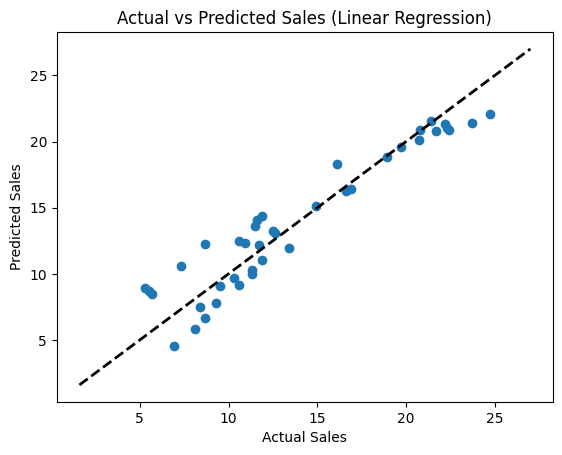

In [16]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales (Linear Regression)")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.show()

In [17]:
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

poly_lr = LinearRegression()
poly_lr.fit(X_poly_train, y_train)

y_pred_poly = poly_lr.predict(X_poly_test)

print("Polynomial Regression R²:", r2_score(y_test, y_pred_poly))
print("MSE:", mean_squared_error(y_test, y_pred_poly))


Polynomial Regression R²: 0.9869181490609598
MSE: 0.4129102285379215


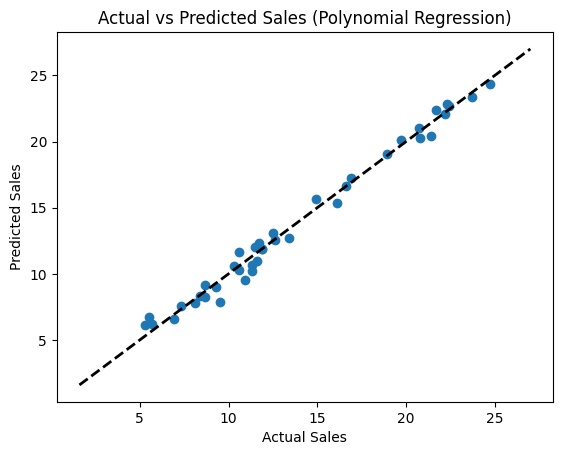

In [19]:
plt.scatter(y_test, y_pred_poly)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales (Polynomial Regression)")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)   
plt.show()

In [20]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree R²:", r2_score(y_test, y_pred_dt))
print("MSE:", mean_squared_error(y_test, y_pred_dt))


Decision Tree R²: 0.9310914968293178
MSE: 2.175


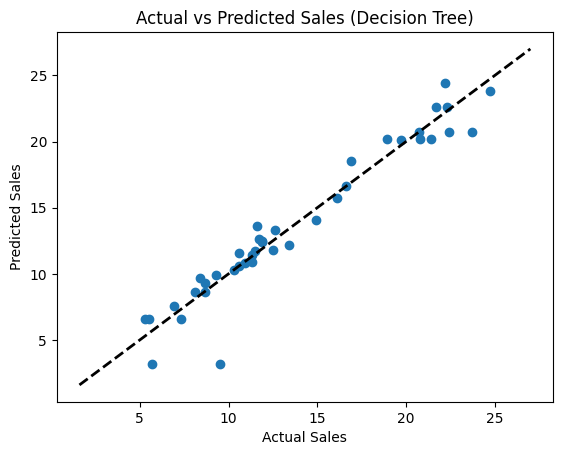

In [22]:
plt.scatter(y_test, y_pred_dt)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales (Decision Tree)")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.show()

In [24]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest R²:", r2_score(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))


Random Forest R²: 0.9812843792541843
MSE: 0.5907322499999988


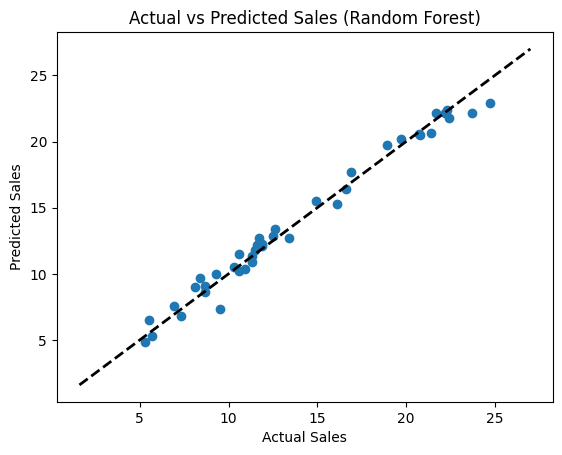

In [25]:
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales (Random Forest)")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.show()

In [26]:
params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 4, 6, 8, 10],
    'min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(estimator=RandomForestRegressor(random_state=42),
                       param_grid=params,
                       cv=5,
                       n_jobs=-1,
                       scoring='r2')

grid_rf.fit(X_train, y_train)

print("Best Parameters:", grid_rf.best_params_)
print("Best R² Score:", grid_rf.best_score_)


Best Parameters: {'max_depth': 8, 'min_samples_split': 2, 'n_estimators': 200}
Best R² Score: 0.9701310364971084


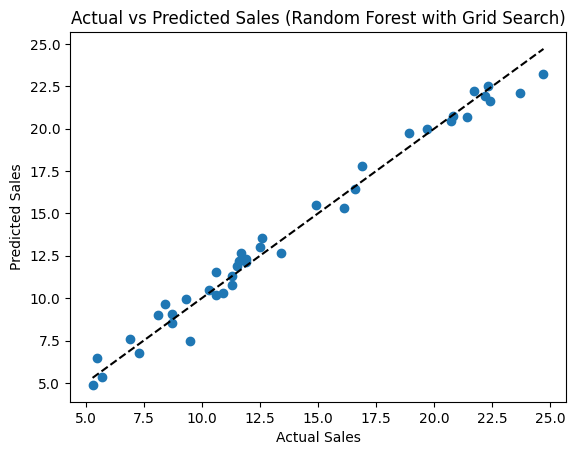

In [36]:
y_pred = grid_rf.best_estimator_.predict(X_test)
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales (Random Forest with Grid Search)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.show()


TV: 0.6251
Radio: 0.3620
Newspaper: 0.0130


Text(0.5, 0, 'Feature Importance')

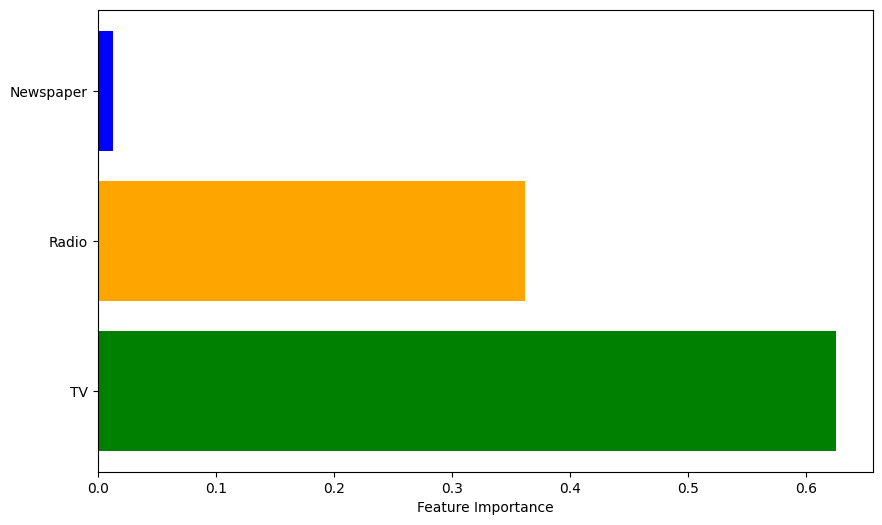

In [33]:
feature_importances = grid_rf.best_estimator_.feature_importances_
for feature, importance in zip(X.columns, feature_importances):
    print(f"{feature}: {importance:.4f}")
plt.figure(figsize=(10, 6))
plt.barh(X.columns, feature_importances, color=['green', 'orange', 'blue'])
plt.xlabel("Feature Importance")


In [37]:
joblib.dump(rf, 'sales_prediction_model.pkl')


['sales_prediction_model.pkl']